1) Clean Data

In [3]:
import pandas as pd

df = pd.read_csv(r"C:\Users\Vedvyass M\OneDrive\Desktop\data_query.csv")

print(df.isnull().sum())
print(df.duplicated().sum())
print(df.describe())

Name           0
Register_ID    0
Maths          0
English        0
Science        0
Attendance     0
dtype: int64
0
        Register_ID      Maths   English    Science  Attendance
count  2.000000e+01  20.000000  20.00000  20.000000   20.000000
mean   2.026010e+06  78.500000  77.85000  79.350000   89.700000
std    5.916080e+00  11.431719  10.39876  11.160433    7.298882
min    2.026001e+06  58.000000  60.00000  57.000000   75.000000
25%    2.026006e+06  69.750000  70.25000  70.750000   84.500000
50%    2.026010e+06  79.500000  78.50000  81.500000   90.500000
75%    2.026015e+06  88.250000  87.25000  87.750000   96.000000
max    2.026020e+06  95.000000  93.00000  96.000000   99.000000


In [4]:
df

,Name,Register_ID,Maths,English,Science,Attendance
0,Arun,2026001,92,88,90,98
1,Bala,2026002,85,82,84,95
2,Charan,2026003,78,75,80,90
3,Deepak,2026004,95,93,96,99
4,Eswar,2026005,70,72,68,85
5,Farhan,2026006,88,90,87,96
6,Gokul,2026007,60,65,62,78
7,Hari,2026008,82,80,84,92
8,Ishaan,2026009,75,78,76,89
9,John,2026010,91,89,92,97


2) Identify Correlations

In [7]:
df["Total"] = df["Maths"] + df["English"] + df["Science"]

correlation = df[["Attendance", "Total"]].corr()

print(correlation)

            Attendance   Total
Attendance      1.0000  0.9927
Total           0.9927  1.0000


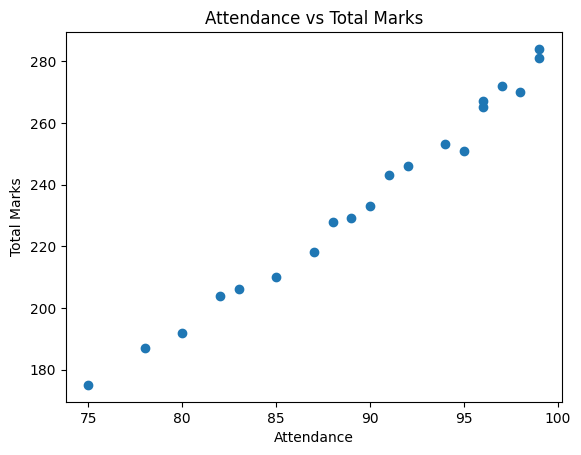

In [9]:
import matplotlib.pyplot as plt

plt.scatter(df["Attendance"], df["Total"])
plt.xlabel("Attendance")
plt.ylabel("Total Marks")
plt.title("Attendance vs Total Marks")
plt.show()

3) Identify Outliers

In [2]:
Q1 = df["Total"].quantile(0.25)
Q3 = df["Total"].quantile(0.75)

IQR = Q3 - Q1

lower = Q1 - 1.5 * IQR
upper = Q3 + 1.5 * IQR

outliers = df[(df["Total"] < lower) | (df["Total"] > upper)]

print(outliers)

NameError: name 'df' is not defined

4) Create Groupings

In [11]:
def grade(total):
    if total >= 270:
        return "Excellent"
    elif total >= 240:
        return "Good"
    elif total >= 210:
        return "Average"
    else:
        return "Needs Improvement"

df["Performance"] = df["Total"].apply(grade)

print(df[["Name","Total","Performance"]])

       Name  Total        Performance
0      Arun    270          Excellent
1      Bala    251               Good
2    Charan    233            Average
3    Deepak    284          Excellent
4     Eswar    210            Average
5    Farhan    265               Good
6     Gokul    187  Needs Improvement
7      Hari    246               Good
8    Ishaan    229            Average
9      John    272          Excellent
10  Karthik    204  Needs Improvement
11   Lokesh    253               Good
12    Manoj    175  Needs Improvement
13   Naveen    218            Average
14  Praveen    267               Good
15    Rahul    243               Good
16    Saran    206  Needs Improvement
17    Tarun    281          Excellent
18     Uday    228            Average
19  Vignesh    192  Needs Improvement


5) Analyze Data

In [13]:
print(df.describe())

print("Average Maths:", df["Maths"].mean())
print("Average English:", df["English"].mean())
print("Average Science:", df["Science"].mean())
print("Average Attendance:", df["Attendance"].mean())

        Register_ID      Maths   English    Science  Attendance       Total
count  2.000000e+01  20.000000  20.00000  20.000000   20.000000   20.000000
mean   2.026010e+06  78.500000  77.85000  79.350000   89.700000  235.700000
std    5.916080e+00  11.431719  10.39876  11.160433    7.298882   32.725493
min    2.026001e+06  58.000000  60.00000  57.000000   75.000000  175.000000
25%    2.026006e+06  69.750000  70.25000  70.750000   84.500000  209.000000
50%    2.026010e+06  79.500000  78.50000  81.500000   90.500000  238.000000
75%    2.026015e+06  88.250000  87.25000  87.750000   96.000000  265.500000
max    2.026020e+06  95.000000  93.00000  96.000000   99.000000  284.000000
Average Maths: 78.5
Average English: 77.85
Average Science: 79.35
Average Attendance: 89.7


6) Separate & Focus Data

In [15]:
low_attendance = df[df["Attendance"] < 85]

print(low_attendance)

       Name  Register_ID  Maths  English  Science  Attendance  Total  \
6     Gokul      2026007     60       65       62          78    187   
10  Karthik      2026011     66       68       70          82    204   
12    Manoj      2026013     58       60       57          75    175   
16    Saran      2026017     69       66       71          83    206   
19  Vignesh      2026020     64       62       66          80    192   

          Performance  
6   Needs Improvement  
10  Needs Improvement  
12  Needs Improvement  
16  Needs Improvement  
19  Needs Improvement  


In [16]:
top_students = df[df["Total"] >= 270]

print(top_students)

      Name  Register_ID  Maths  English  Science  Attendance  Total  \
0     Arun      2026001     92       88       90          98    270   
3   Deepak      2026004     95       93       96          99    284   
9     John      2026010     91       89       92          97    272   
17   Tarun      2026018     94       92       95          99    281   

   Performance  
0    Excellent  
3    Excellent  
9    Excellent  
17   Excellent  


7) Insights & Decisions

From this dataset, you can conclude:

Students with higher attendance generally score higher marks.

Attendance and total marks show a strong positive correlation.

Students with attendance below 85% generally have lower academic performance.

Teachers can identify students needing attendance improvement.

Academic interventions can focus on students with both low attendance and low marks.

Sample Correlation Result

| Variables                 | Correlation                                   |
| ------------------------- | --------------------------------------------- |
| Attendance vs Total Marks | **≈ 0.93–0.97 (Strong Positive Correlation)** |

